# Linear Regression: Our First Predictive Model

In the previous notebook, we prepared the Buenos Aires dataset: merged multiple CSV files, filtered to a homogeneous market segment, removed outliers, extracted geographic features, and created a clean train-test split. That preparation work exists for one purpose — to enable what happens in this notebook.

**We are going to teach a machine to predict apartment prices.**

In this notebook we'll focus on **one feature** (`surface_covered_in_m2`) rather than all available features. This is intentional. Starting with a single variable lets us visualize exactly what the model is doing — we can draw the predictions as a line on a scatter plot, see where the model is right and where it is wrong, and build genuine intuition before adding complexity.

### Setup: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## 1. Preparing the Data

In [3]:
import sys
import os

parent_dir = os.path.abspath('..')

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [4]:
# Load the data
from src.wrangle import clean_files
df = clean_files("../data/buenos-aires-real-estate-*.csv")  
df.info()

<class 'pandas.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighborhood           6247 non-null   str    
dtypes: float64(4), str(1)
memory usage: 292.8 KB


### 1.1 Creating the Feature Matrix and Target Vector

In [5]:
# Create the feature matrix
X = df[["surface_covered_in_m2"]] 

# Create the target vector
y = df["price_aprox_usd"]  

### 1.2 Train-Test Split

In [6]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 4997
Test set size: 1250


## 2. Establishing a Baseline

Before building any model, we need a **baseline** — the simplest possible prediction strategy — as a performance benchmark.

In [7]:
y_mean = y_train.mean()  
print("Mean house price:", y_mean)

Mean house price: 134635.8685691415


### 2.1 Measuring Baseline Performance: MAE

In [8]:
# Create predictions (all the same mean value) for the TEST set
y_pred_baseline = [y_mean] * len(y_test)

# Calculate Mean Absolute Error
mae_baseline = mean_absolute_error(y_test, y_pred_baseline) 

print("Baseline MAE:", mae_baseline)

Baseline MAE: 44515.61274011767


## 3. Building the Model: Linear Regression

Now we train our first actual predictive model.

In [10]:
# Instantiate the model
model_lr = LinearRegression()  

# Fit the model
model_lr.fit(X_train, y_train) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2282.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['surface_covered_in_m2']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.07e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## 4. Evaluating the Model

### The Three Metrics We Will Use

- **MAE (Mean Absolute Error)**

- **RMSE (Root Mean Squared Error)**

- **R² (Coefficient of Determination)**

### 4.1 Train Set Performance


In [11]:
# Generate predictions on training data
y_pred_train = model_lr.predict(X_train)  

# Calculate training metrics
mae_train = mean_absolute_error(y_train, y_pred_train)  
rmse_train = root_mean_squared_error(y_train, y_pred_train) 
r2_train = r2_score(y_train, y_pred_train)  

print(f"Training MAE: ${mae_train:,.2f}")
print(f"Training RMSE: ${rmse_train:,.2f}")
print(f"Training R²: {r2_train:.4f}")

Training MAE: $31,161.18
Training RMSE: $43,087.89
Training R²: 0.4791


### 4.2 Test Set Performance


In [12]:
# Generate predictions on test data
y_pred_test = model_lr.predict(X_test) 

# Calculate test metrics
mae_test = mean_absolute_error(y_test, y_pred_test)  
rmse_test = root_mean_squared_error(y_test, y_pred_test) 
r2_test = r2_score(y_test, y_pred_test) 

print(f"Test MAE: ${mae_test:,.2f}")
print(f"Test RMSE: ${rmse_test:,.2f}")
print(f"Test R²: {r2_test:.4f}")

Test MAE: $30,176.98
Test RMSE: $41,814.02
Test R²: 0.4720


### 4.3 Diagnosing the Model: Training vs. Test Gap

The most important comparison is between training and test metrics. Three patterns are possible:

In [13]:
# Create comparison DataFrame
metrics_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Training': [mae_train, rmse_train, r2_train], 
    'Test': [mae_test, rmse_test, r2_test]  
})

print(metrics_comparison)

# Calculate the difference
print(f"\nRMSE difference (Test - Train): ${rmse_test - rmse_train:,.2f}")

  Metric      Training          Test
0    MAE  31161.180943  30176.983140
1   RMSE  43087.894408  41814.016022
2     R²      0.479095      0.471974

RMSE difference (Test - Train): $-1,273.88


## 5. Communicating Results

### 5.1 Model Parameters: Intercept and Coefficient

In [14]:
intercept = model_lr.intercept_  
coefficient = model_lr.coef_[0]  

print(f"Intercept: ${intercept:,.2f}")
print(f"Coefficient: ${coefficient:,.2f} per square meter")

Intercept: $10,695.28
Coefficient: $2,282.21 per square meter


### 5.2 Predicted vs. Actual Plot

The predicted-vs-actual scatter plot is one of the most informative model diagnostics available. It compares the model's predictions (y-axis) to the true prices (x-axis).

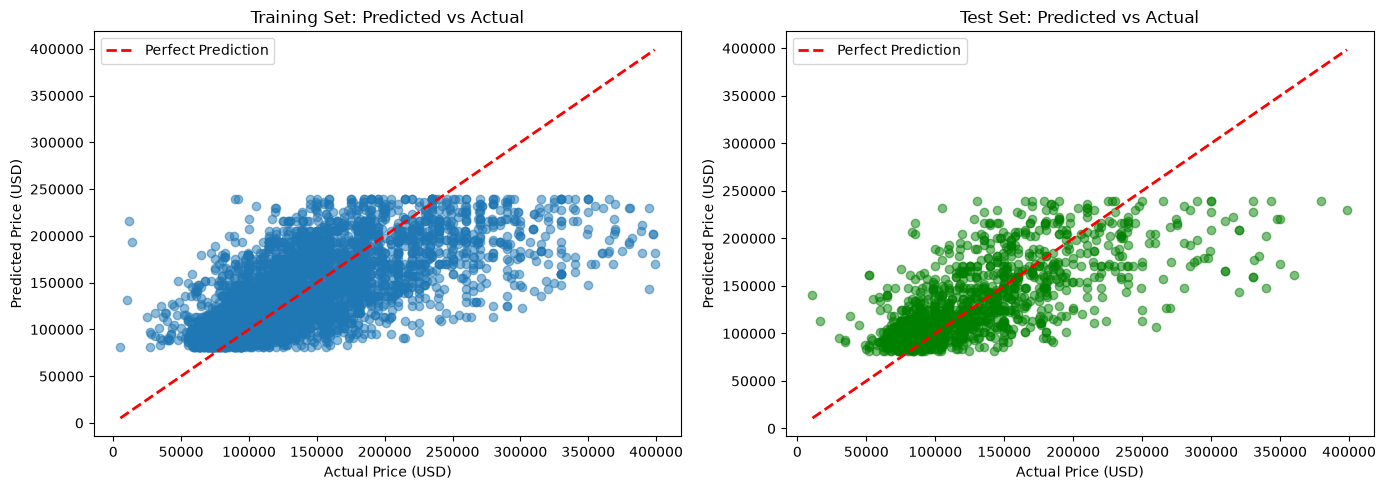

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_pred_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('Training Set: Predicted vs Actual')
axes[0].legend()

# Test set
axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].set_title('Test Set: Predicted vs Actual')
axes[1].legend()

plt.tight_layout()

### 5.3 Residual Analysis

Residual plots reveal patterns that aggregate metrics like MAE and RMSE hide. A model might have an acceptable average error while still systematically underestimating expensive apartments or overestimating cheap ones. Those systematic errors indicate that the model is missing an important relationship in the data.


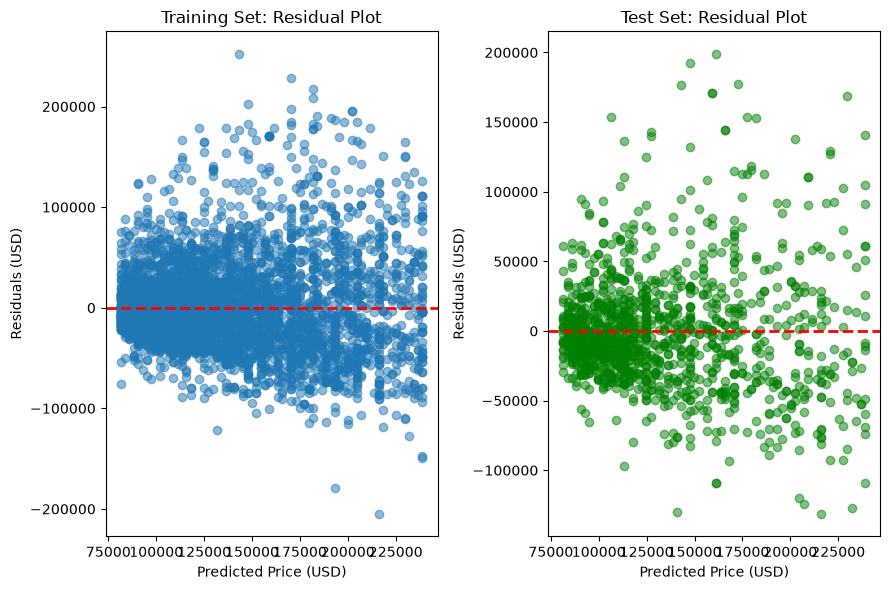

In [16]:
residuals_train = y_train - y_pred_train  
residuals_test = y_test - y_pred_test  

fig, axes = plt.subplots(1, 2, figsize=(9, 6))

# Training residuals
axes[0].scatter(y_pred_train, residuals_train, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residuals (USD)')
axes[0].set_title('Training Set: Residual Plot')

# Test residuals
axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residuals (USD)')
axes[1].set_title('Test Set: Residual Plot')

plt.tight_layout()

### 5.4 Line of Best Fit

The final visualization places the model's predictions as a line over the original scatter plot — this is the "line of best fit" that linear regression has learned from the training data.

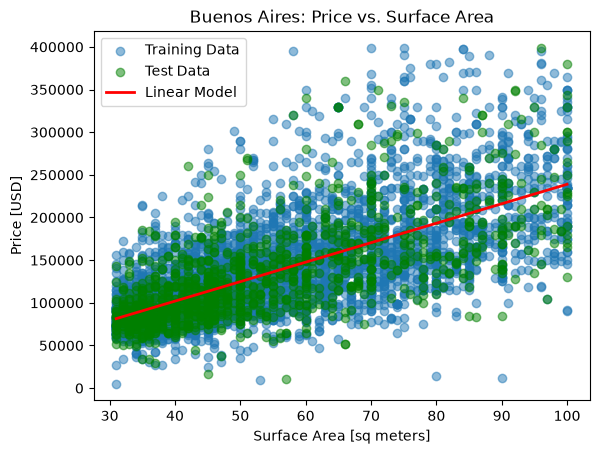

In [17]:
fig, ax = plt.subplots()
ax.scatter(X_train, y_train, alpha=0.5, label='Training Data')
ax.scatter(X_test, y_test, alpha=0.5, color='green', label='Test Data')

# Create evenly-spaced x values for the line
x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=X_train.columns)
ax.plot(x_line, model_lr.predict(x_line_df), color="red", linewidth=2, label="Linear Model")

ax.set_xlabel("Surface Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Buenos Aires: Price vs. Surface Area")
ax.legend();

## Summary

**A single feature is not enough** — the residual patterns we observed indicate that size alone cannot fully explain apartment prices; neighborhood, location, and other characteristics also matter
